# DenseNet-121 KL Grading Reproduction

## Configuration Summary

| Item | Configuration |
| --- | --- |
| Task | Five-class Kellgren-Lawrence grade classification (0-4) |
| Backbone | ImageNet-pretrained DenseNet-121 |
| Classifier head | Flattened convolutional features -> 128 -> 64 -> 16 -> 5; ReLU and Dropout(0.30) after hidden layers |
| Input | Grayscale converted to 3 channels, 224 x 224 |
| Preprocessing | Resize; optional Otsu threshold plus morphological opening; no center crop; tensor normalization to [-1, 1] |
| Augmentation | Rotation +/-30 degrees, affine translation +/-10%, scale 0.8-1.2, shear +/-20 degrees, horizontal flip |
| Loss | Categorical cross-entropy |
| Optimizer | Adam, learning rate 1e-4, weight decay 1e-4 |
| Schedule | ReduceLROnPlateau, factor 0.1, patience 3 |
| Stopping | Early stopping after 8 validation-loss epochs without improvement |
| Split | Stratified 80% development / 20% test, then 90% train / 10% validation |
| Explainability | This reproduction reports classification metrics; it does not replace the production Grad-CAM notebook |

This follows the DenseNet-121 KL-grading paper recipe where specified. The paper used a different 301-patient dataset; this run uses the local KL image dataset, so published scores are not expected to match. Values not specified by the paper are explicit experiment choices in the configuration cell.

## Run

Run all cells from top to bottom in a fresh Colab GPU runtime.



In [1]:
!pip -q install timm scikit-learn opencv-python-headless


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import copy
import json
import matplotlib.pyplot as plt
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
DATA_ROOT = Path('/content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1/extracted/KneeXrayData/ClsKLData/kneeKL224')
RUN_DIR = Path('/content/drive/MyDrive/Models/paper_fmed_densenet121') / pd.Timestamp.utcnow().strftime('%Y-%m-%d_%H-%M-%S_UTC')
INPUT_SIZE = 224
BATCH_SIZE = 32                         # not reported by the paper
MAX_EPOCHS = 50                         # early stopping controls the final epoch
LEARNING_RATE = 1e-4                    # paper says reduced LR but gives no value
WEIGHT_DECAY = 1e-4                     # paper: L2 lambda = 1e-4
EARLY_STOPPING_PATIENCE = 8
USE_PAPER_MORPHOLOGY = True             # Otsu + opening described in the paper

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Kaggle/224 dataset not found: {DATA_ROOT}')
RUN_DIR.mkdir(parents=True, exist_ok=False)
print('Device:', DEVICE)
print('Run directory:', RUN_DIR)


Mounted at /content/drive
Device: cuda
Run directory: /content/drive/MyDrive/Models/paper_fmed_densenet121/2026-08-07_04-11-48_UTC


## Paper preprocessing and augmentation

The source paper describes resizing to 224, grayscale conversion, Otsu thresholding with morphological opening, zero-padding, and normalization to [0, 1]. Training augmentation is rotation up to +/-30 degrees, zoom 0.8-1.2, affine translation up to 10%, shear up to +/-20 degrees, and horizontal flipping. The test split is created before augmentation.

The repository safeguard against destructive center crops is respected: padding and affine transforms preserve marginal anatomy.


In [3]:
def paper_preprocess(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise RuntimeError(f'Cannot decode {path}')
    image = cv2.resize(image, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_AREA)
    if USE_PAPER_MORPHOLOGY:
        _, mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        image = cv2.bitwise_and(image, image, mask=mask)
    return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

def pad_to_square(image):
    h, w = image.shape[:2]
    side = max(h, w)
    top, left = (side - h) // 2, (side - w) // 2
    return cv2.copyMakeBorder(image, top, side-h-top, left, side-w-left, cv2.BORDER_CONSTANT, value=(0, 0, 0))

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.10, 0.10), scale=(0.8, 1.2), shear=20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),
])
eval_transform = transforms.Compose([
    transforms.ToPILImage(), transforms.ToTensor(), transforms.Normalize([0.5] * 3, [0.5] * 3),
])

records = []
for path in sorted(DATA_ROOT.glob('*/*/*.png')):
    try:
        grade = int(path.parent.name)
    except ValueError:
        continue
    if grade in range(5): records.append({'path': str(path), 'grade': grade})
frame = pd.DataFrame(records)
if frame.empty:
    raise RuntimeError(f'No grade/PNG files found below {DATA_ROOT}')
development, test = train_test_split(frame, test_size=0.20, random_state=SEED, stratify=frame.grade)
train_frame, val_frame = train_test_split(development, test_size=0.10, random_state=SEED, stratify=development.grade)
print('split sizes:', len(train_frame), len(val_frame), len(test))

class KneeDataset(Dataset):
    def __init__(self, rows, transform): self.rows = rows.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.rows)
    def __getitem__(self, index):
        row = self.rows.iloc[index]
        return self.transform(paper_preprocess(row.path)), int(row.grade)

train_loader = DataLoader(KneeDataset(train_frame, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(KneeDataset(val_frame, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(KneeDataset(test, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


split sizes: 7045 783 1958


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

model.safetensors: downloading bytes:           |  0.00B            

{'epoch': 1, 'train_loss': 1.4230969324782015, 'val_loss': 1.2633473009898746, 'val_accuracy': 0.4482758620689655, 'val_auc_ovr': np.float64(0.747100681945825)}
{'epoch': 2, 'train_loss': 1.3140453341668847, 'val_loss': 1.1459407615326678, 'val_accuracy': 0.5019157088122606, 'val_auc_ovr': np.float64(0.7946582300918553)}
{'epoch': 3, 'train_loss': 1.2433499113222315, 'val_loss': 1.0665040335892717, 'val_accuracy': 0.5683269476372924, 'val_auc_ovr': np.float64(0.8152655599270873)}
{'epoch': 4, 'train_loss': 1.1950683127065513, 'val_loss': 1.1666546912333366, 'val_accuracy': 0.4840357598978289, 'val_auc_ovr': np.float64(0.7879228486466193)}
{'epoch': 5, 'train_loss': 1.1663244412417442, 'val_loss': 1.0331837145913758, 'val_accuracy': 0.5606641123882503, 'val_auc_ovr': np.float64(0.8156525422230307)}
{'epoch': 6, 'train_loss': 1.134837274267117, 'val_loss': 1.0769335051301492, 'val_accuracy': 0.5351213282247765, 'val_auc_ovr': np.float64(0.8200051877108562)}
{'epoch': 7, 'train_loss': 1.1

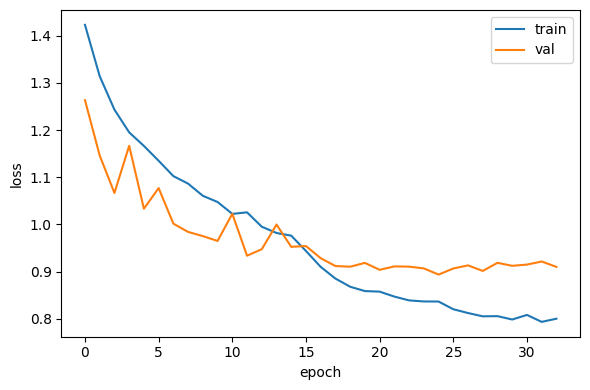

In [4]:
class PaperDenseNet121(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('densenet121', pretrained=True, num_classes=0, global_pool='')
        with torch.no_grad():
            feature_shape = self.backbone(torch.zeros(1, 3, INPUT_SIZE, INPUT_SIZE)).shape
        flattened = int(np.prod(feature_shape[1:]))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened, 128), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(64, 16), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(16, 5),
        )
    def forward(self, images): return self.head(self.backbone(images))

model = PaperDenseNet121().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
criterion = nn.CrossEntropyLoss()

def evaluate(loader):
    model.eval(); losses=[]; labels=[]; probabilities=[]
    with torch.no_grad():
        for images, target in loader:
            logits = model(images.to(DEVICE)); target = target.to(DEVICE)
            losses.append(float(criterion(logits, target).item()) * len(target))
            labels.extend(target.cpu().numpy()); probabilities.extend(F.softmax(logits, 1).cpu().numpy())
    labels=np.asarray(labels); probabilities=np.asarray(probabilities); predictions=probabilities.argmax(1)
    return {'loss': sum(losses)/len(labels), 'accuracy': accuracy_score(labels, predictions), 'auc_ovr': roc_auc_score(labels, probabilities, multi_class='ovr'), 'labels': labels, 'probabilities': probabilities, 'predictions': predictions}

best_state = None; best_val = float('inf'); stale = 0; history=[]
for epoch in range(1, MAX_EPOCHS + 1):
    model.train(); total=0.0; count=0
    for images, target in train_loader:
        optimizer.zero_grad(set_to_none=True); target=target.to(DEVICE)
        loss=criterion(model(images.to(DEVICE)), target); loss.backward(); optimizer.step()
        total += loss.item()*len(target); count += len(target)
    val = evaluate(val_loader); scheduler.step(val['loss'])
    row={'epoch':epoch,'train_loss':total/count,'val_loss':val['loss'],'val_accuracy':val['accuracy'],'val_auc_ovr':val['auc_ovr']}; history.append(row)
    print(row)
    if val['loss'] < best_val:
        best_val=val['loss']; stale=0; best_state=copy.deepcopy(model.state_dict()); torch.save({'model_state_dict':best_state,'epoch':epoch,'paper':'fmed-12-1707588','config':row}, RUN_DIR/'best_model.pth')
    else: stale += 1
    if stale >= EARLY_STOPPING_PATIENCE: print('Early stopping at epoch', epoch); break

test_metrics=evaluate(test_loader); predictions=test_metrics.pop('predictions'); labels=test_metrics.pop('labels'); probabilities=test_metrics.pop('probabilities')
print(json.dumps({k:float(v) for k,v in test_metrics.items()}, indent=2))
print(classification_report(labels, predictions, labels=range(5), zero_division=0))
pd.DataFrame(history).to_csv(RUN_DIR/'history.csv', index=False)
pd.DataFrame(confusion_matrix(labels, predictions, labels=range(5))).to_csv(RUN_DIR/'confusion_matrix.csv', index=False)
with open(RUN_DIR/'run_config.json','w') as handle: json.dump({'paper':'fmed-12-1707588','model':'DenseNet121','input_size':224,'loss':'categorical_cross_entropy','optimizer':'Adam','learning_rate':LEARNING_RATE,'weight_decay':WEIGHT_DECAY,'early_stopping_patience':EARLY_STOPPING_PATIENCE,'morphology':USE_PAPER_MORPHOLOGY,'test_metrics':test_metrics}, handle, indent=2)
plt.figure(figsize=(6,4)); plt.plot([r['train_loss'] for r in history], label='train'); plt.plot([r['val_loss'] for r in history], label='val'); plt.legend(); plt.xlabel('epoch'); plt.ylabel('loss'); plt.tight_layout(); plt.savefig(RUN_DIR/'loss_curve.png', dpi=160); plt.show()
